# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


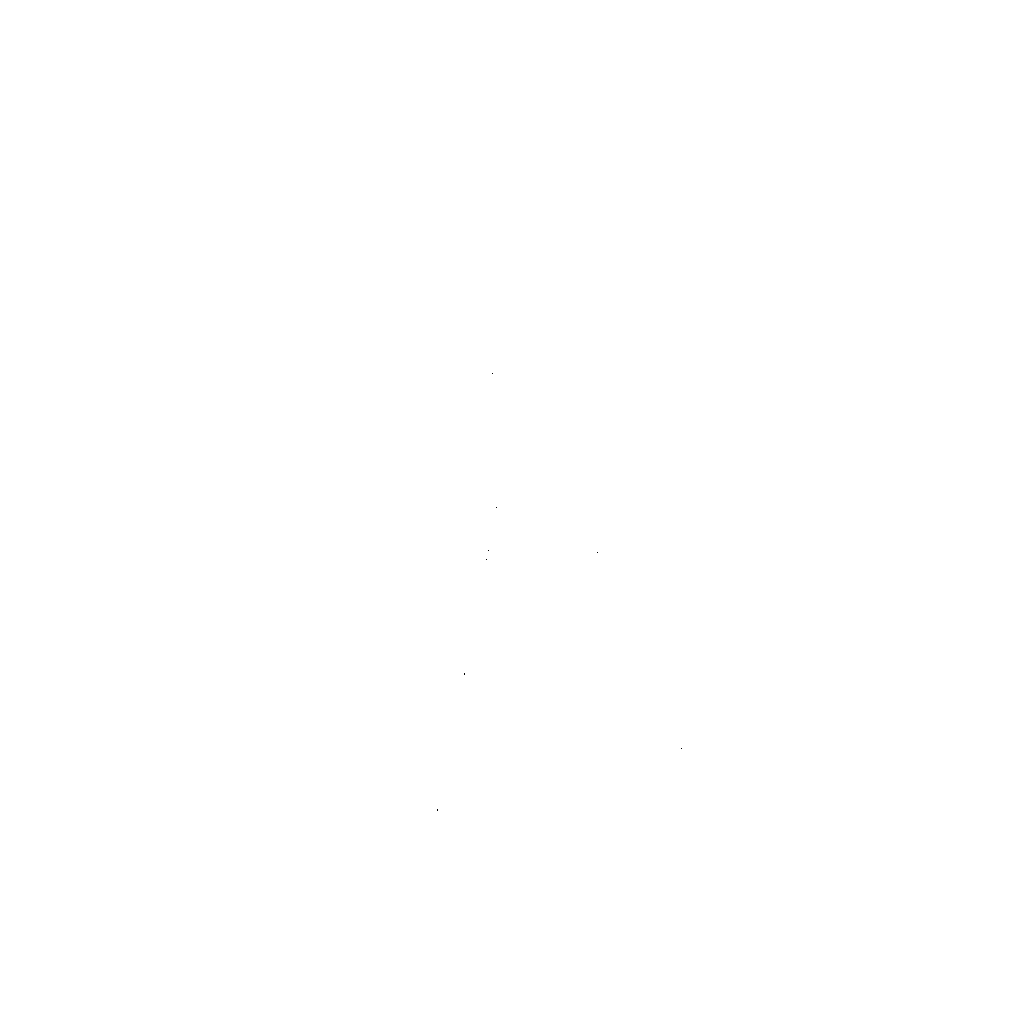

Threshold value: 50


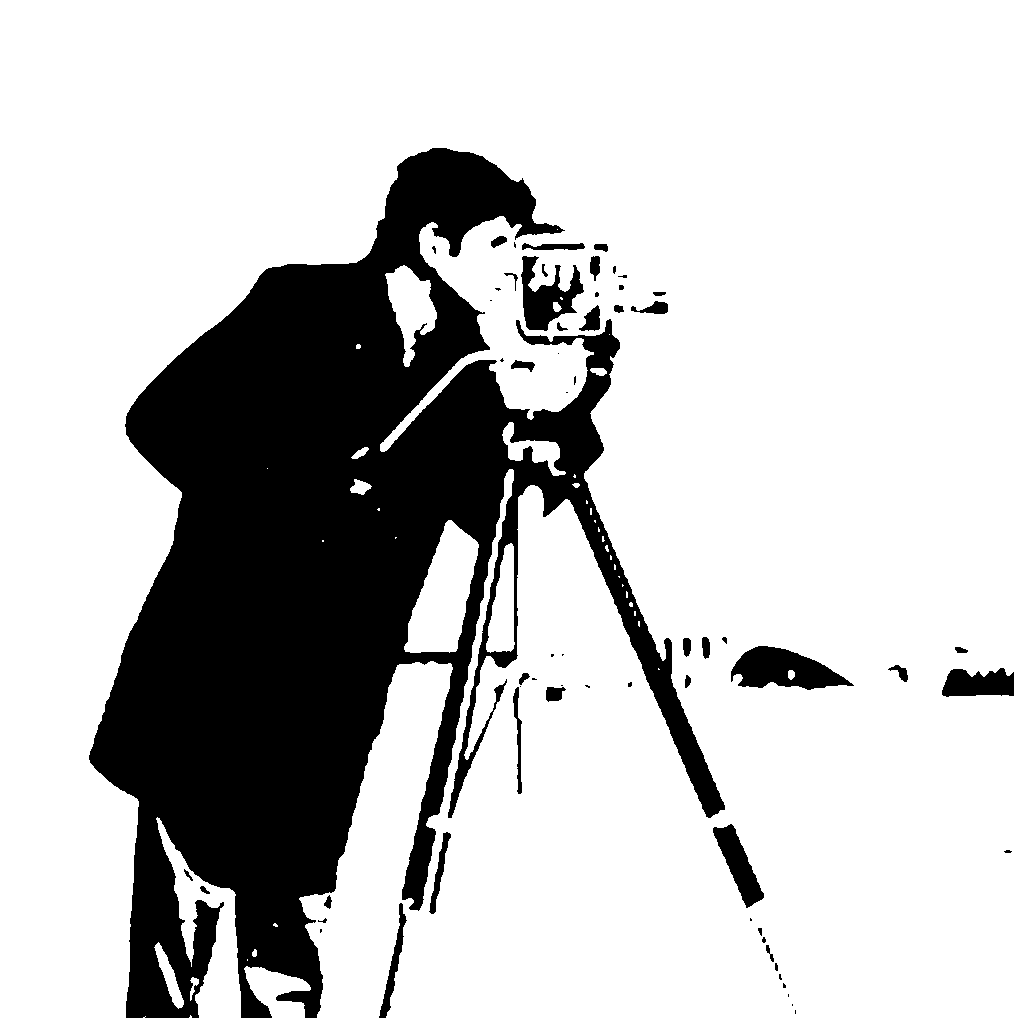

Threshold value: 100


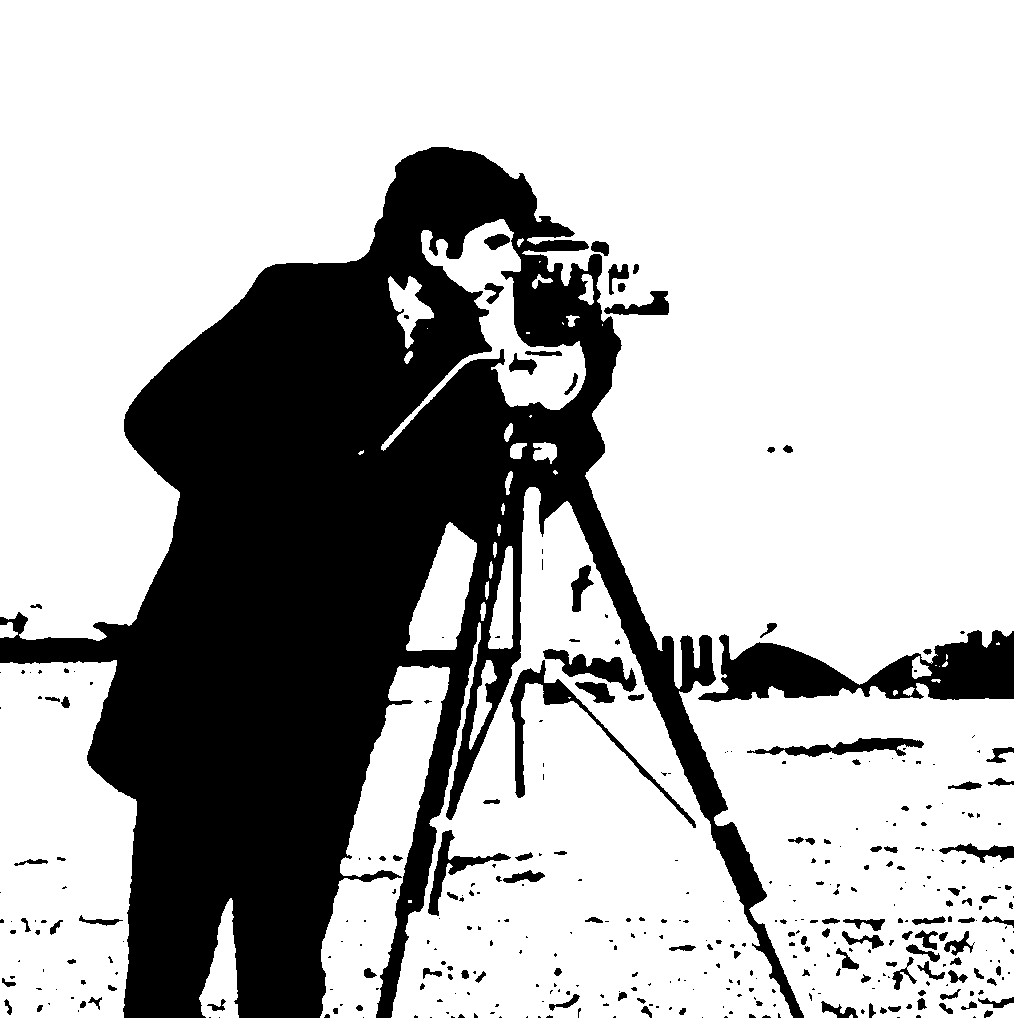

Threshold value: 150


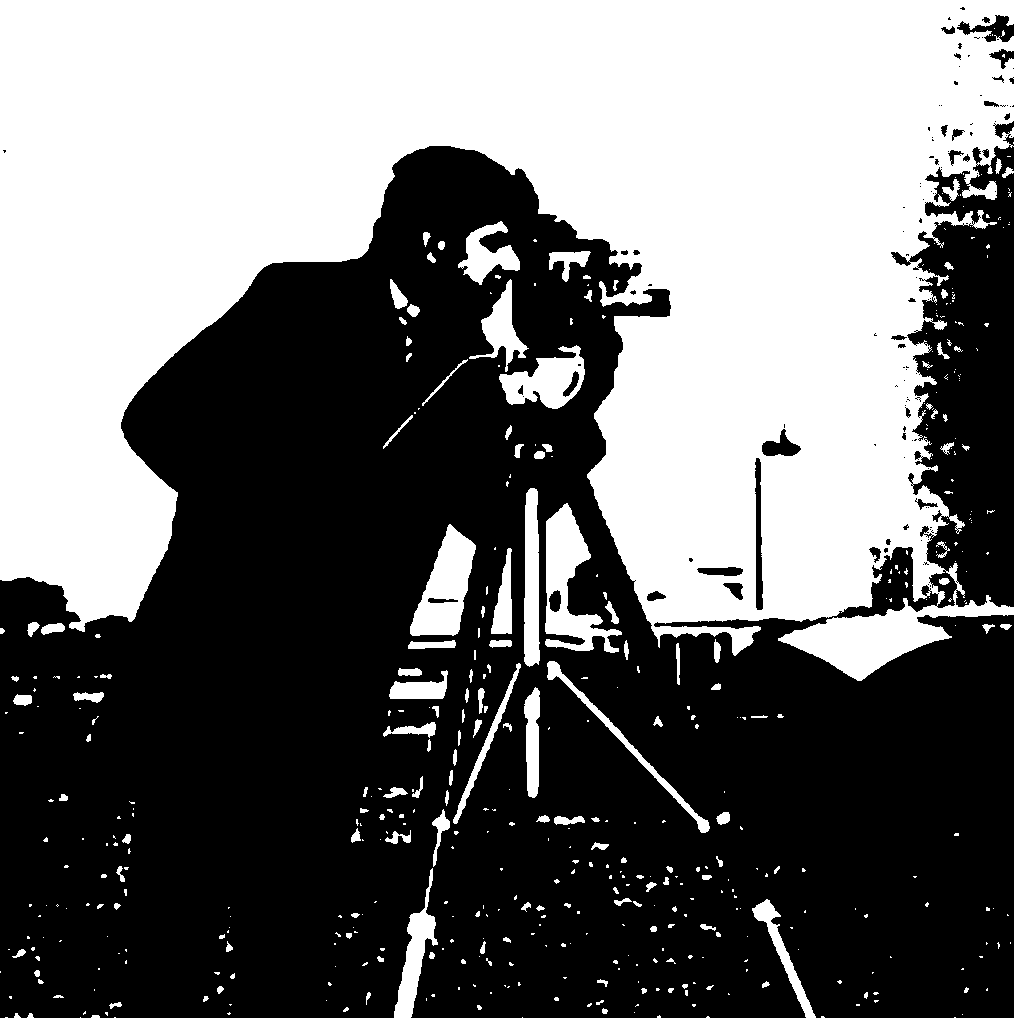

Threshold value: 200


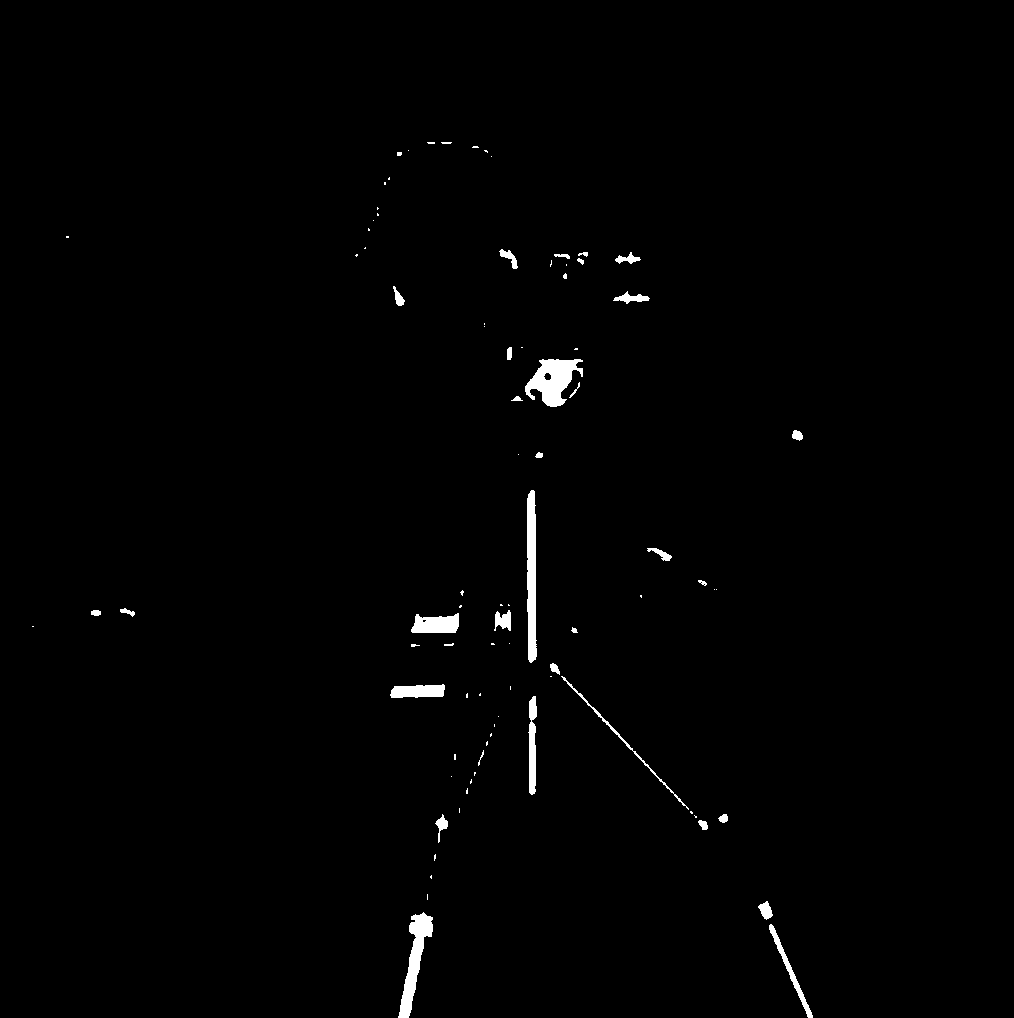

In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


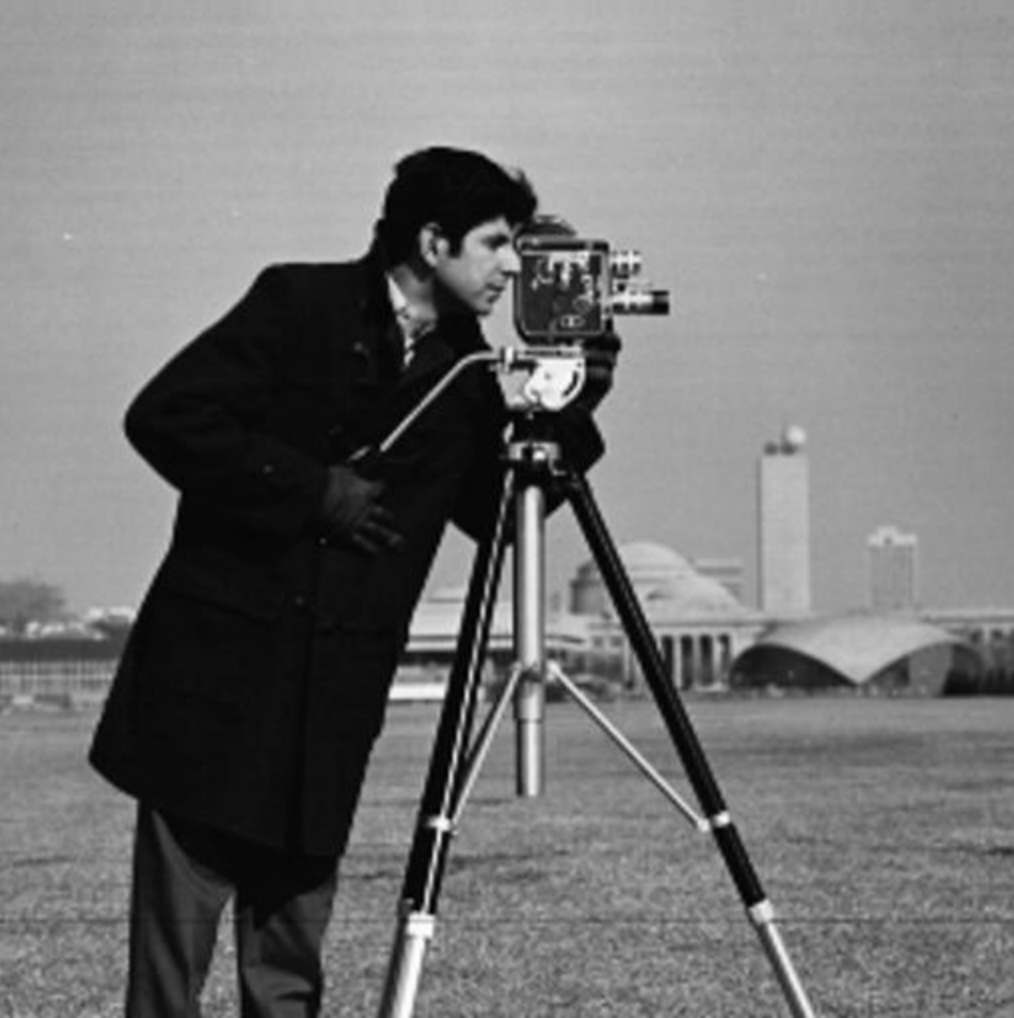

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

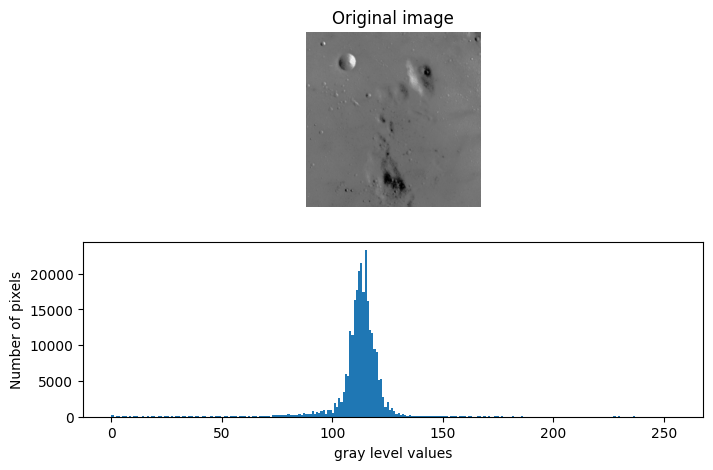

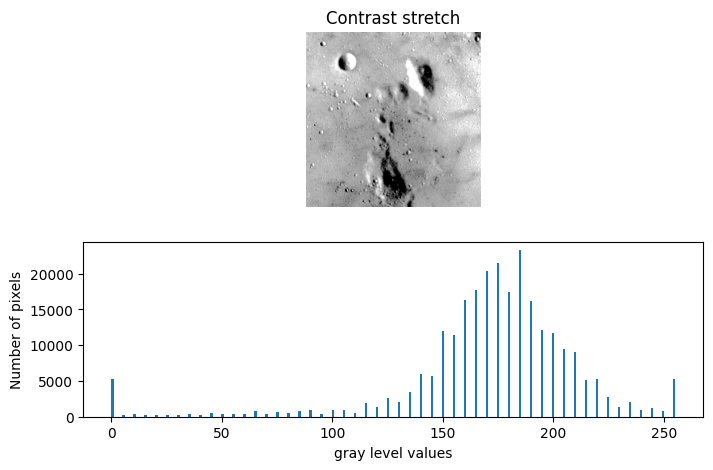

In [1]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

moon = data.moon()

######Task 1 — Rescale intensity using the 3rd and 80th percentiles

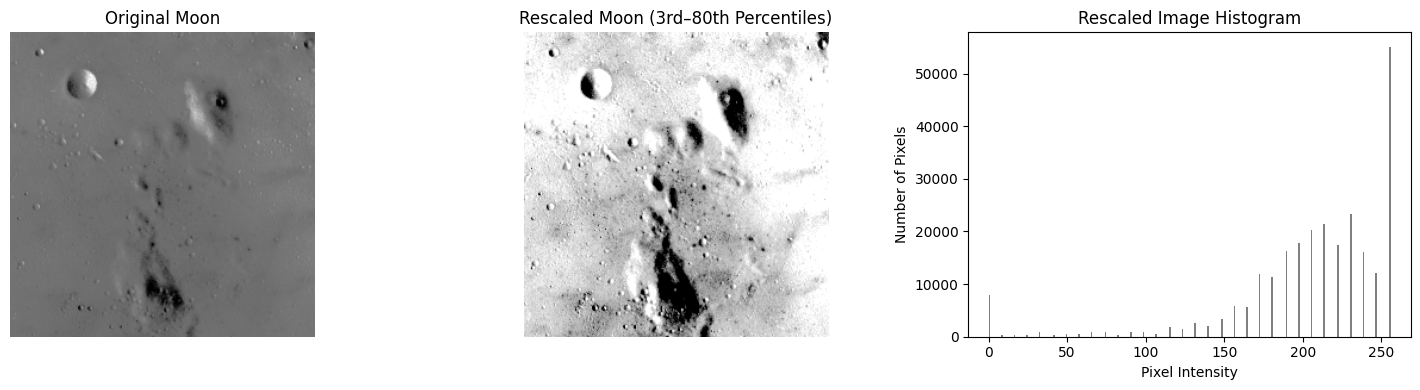

In [5]:
# Calculate the 3rd and 80th percentiles
p3, p80 = np.percentile(moon, (3, 80))

# Stretch the selected intensity range to 0–255
moon_rescaled = exposure.rescale_intensity(
  moon,
  in_range=(p3, p80),
  out_range=(0, 255)
  )

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(moon, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Moon")
axes[0].axis("off")

axes[1].imshow(moon_rescaled, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Rescaled Moon (3rd–80th Percentiles)")
axes[1].axis("off")

axes[2].hist(
    moon_rescaled.ravel(), bins=256, range=(0, 256), color="gray"
    )
axes[2].set_title("Rescaled Image Histogram")
axes[2].set_xlabel("Pixel Intensity")
axes[2].set_ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

#####Task 2 — Histogram equalization

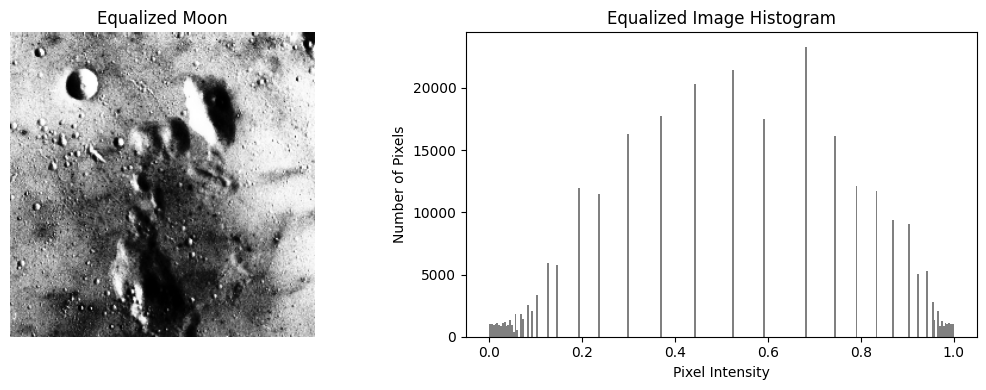

In [8]:
# Equalize the original moon image
moon_equalized = exposure.equalize_hist(moon)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(moon_equalized, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Equalized Moon")
axes[0].axis("off")

axes[1].hist(
    moon_equalized.ravel(), bins=256, range=(0, 1), color="gray"
    )
axes[1].set_title("Equalized Image Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

#####Task 3 — Histogram matching

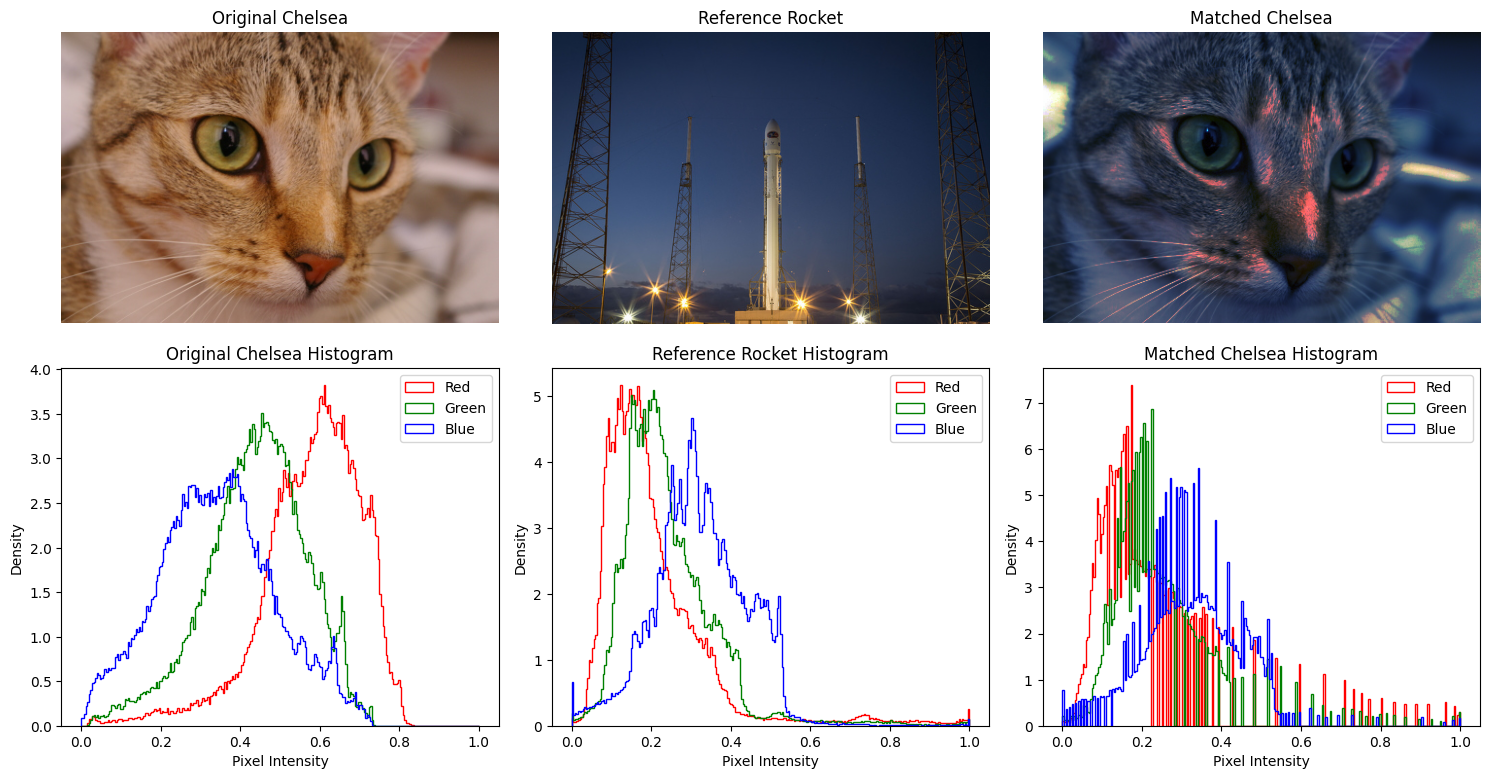

In [10]:
# Convert both images to floating-point values in [0, 1]
chelsea = img_as_float(data.chelsea())
rocket = img_as_float(data.rocket())

# Match Chelsea's histogram to Rocket's histogram
matched = exposure.match_histograms(
    chelsea,
    rocket,
    channel_axis=-1
)

images = [chelsea, rocket, matched]
titles = ["Original Chelsea", "Reference Rocket", "Matched Chelsea"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for column, (image, title) in enumerate(zip(images, titles)):
    axes[0, column].imshow(image)
    axes[0, column].set_title(title)
    axes[0, column].axis("off")

    # Plot each color channel separately
    for channel, color in enumerate(["red", "green", "blue"]):
        axes[1, column].hist(
            image[:, :, channel].ravel(),
            bins=256,
            range=(0, 1),
            density=True,
            histtype="step",
            color=color,
            label=color.capitalize()
        )

    axes[1, column].set_title(f"{title} Histogram")
    axes[1, column].set_xlabel("Pixel Intensity")
    axes[1, column].set_ylabel("Density")
    axes[1, column].legend()

plt.tight_layout()
plt.show()